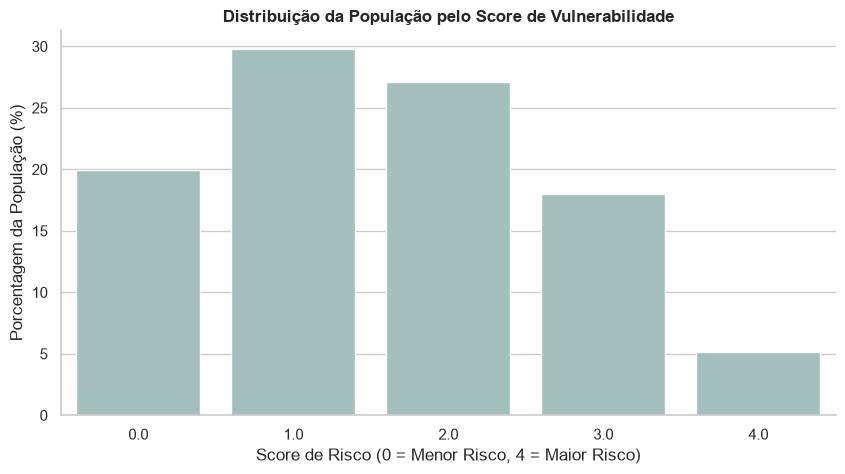

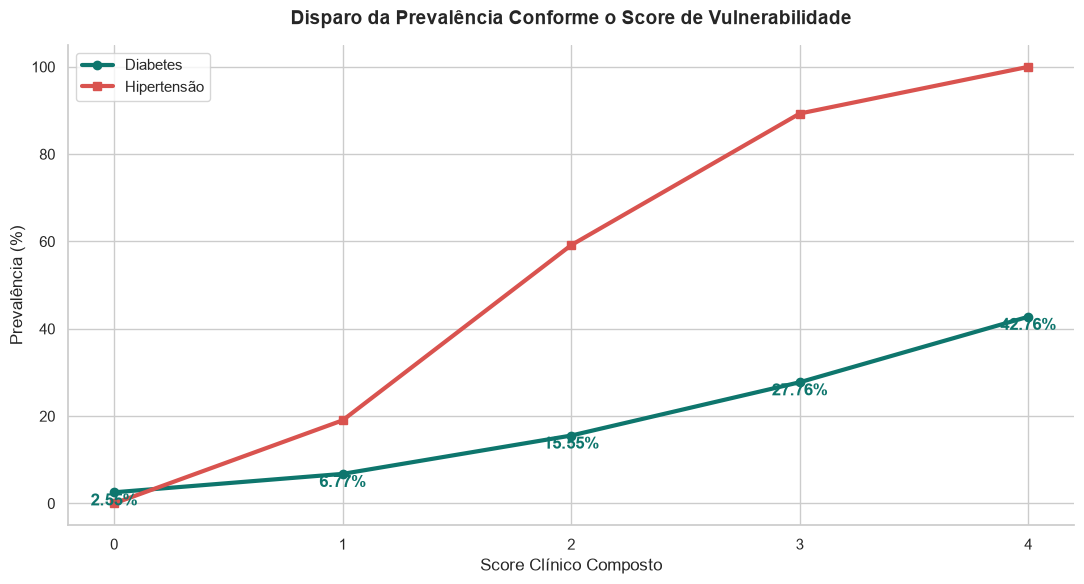

--- Tabela Final: Score de Vulnerabilidade ---


,Score,n,pct_distribuicao,pct_diabetes,pct_hipertensao
0,0.0,50684,19.98,2.55,0.00
1,1.0,75651,29.82,6.77,19.04
2,2.0,68667,27.07,15.55,59.16
3,3.0,45576,17.97,27.76,89.30
4,4.0,13102,5.16,42.76,100.00


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Setup, Carga dos Dados e CORES (Obrigatório em novos arquivos)
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

# Aplicando o padrão visual do HealthSync
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)

# Declarando as cores para evitar o NameError
cor_primaria = '#0E766D'
cor_secundaria = '#D9534F'

# 2. Construção do Score Sintético
df_score = df.copy()
df_score['Score'] = (
    df_score['HighBP'] +
    df_score['HighChol'] +
    (df_score['BMI'] > 30).astype(int) +
    df_score['Smoker']
)

# 3. Agrupando resultados por Score
tabela_score = df_score.groupby('Score').agg(
    n=('Diabetes_binary', 'size'),
    pct_diabetes=('Diabetes_binary', 'mean'),
    pct_hipertensao=('HighBP', 'mean')
).reset_index()

tabela_score['pct_diabetes'] = (tabela_score['pct_diabetes'] * 100).round(2)
tabela_score['pct_hipertensao'] = (tabela_score['pct_hipertensao'] * 100).round(2)
tabela_score['pct_distribuicao'] = (tabela_score['n'] / len(df_score) * 100).round(2)

# 4. Gráfico A: Distribuição da População pelo Score
plt.figure(figsize=(10, 5))
sns.barplot(data=tabela_score, x='Score', y='pct_distribuicao', color='#A0C4C1')
plt.title('Distribuição da População pelo Score de Vulnerabilidade', fontweight='bold')
plt.ylabel('Porcentagem da População (%)')
plt.xlabel('Score de Risco (0 = Menor Risco, 4 = Maior Risco)')
sns.despine()
plt.show()

# 5. Gráfico B: Evolução do Risco (Score vs Doenças)
plt.figure(figsize=(11, 6))
plt.plot(tabela_score['Score'], tabela_score['pct_diabetes'], marker='o', linewidth=3, label='Diabetes', color=cor_primaria)
plt.plot(tabela_score['Score'], tabela_score['pct_hipertensao'], marker='s', linewidth=3, label='Hipertensão', color=cor_secundaria)

# Adicionando os valores na linha de diabetes
for i, val in enumerate(tabela_score['pct_diabetes']):
    plt.text(i, val - 3, f"{val}%", ha='center', color=cor_primaria, fontweight='bold')

plt.title('Disparo da Prevalência Conforme o Score de Vulnerabilidade', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Prevalência (%)')
plt.xlabel('Score Clínico Composto')
plt.xticks(tabela_score['Score'])
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

# 6. Tabela Resumo do Score
print("--- Tabela Final: Score de Vulnerabilidade ---")
display(tabela_score[['Score', 'n', 'pct_distribuicao', 'pct_diabetes', 'pct_hipertensao']])

In [ ]:
# Score Composto de Vulnerabilidade

#A finalidade deste último eixo é consolidar a Análise Exploratória validando matematicamente a criação de um **Score Sintético de Risco**. Esse índice agrega as variáveis críticas de saúde validadas nos Eixos anteriores (Pressão Alta, Colesterol Alto, Obesidade e Tabagismo).

'O cálculo aditivo é definido por:
"$Score = HighBP + HighChol + I(BMI > 30) + Smoker$

#A validação dessa métrica serve como suporte lógico para o escalonamento de risco implementado na regra de negócio da aplicação.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Setup
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015'
                 '.csv')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
cor_primaria = '#0E766D'
cor_secundaria = '#D9534F'

# Construção do Score Sintético
df_score = df.copy()
df_score['Score'] = (
    df_score['HighBP'] +
    df_score['HighChol'] +
    (df_score['BMI'] > 30).astype(int) +
    df_score['Smoker']
)

In [ ]:
## 1. Distribuição Populacional e Disparo da Prevalência
#Com o Score (variando de 0 a 4) criado, podemos observar como a população se distribui e, o mais importante, como a prevalência de Diabetes e Hipertensão responde de forma exponencial ao acúmulo de fatores de vulnerabilidade.

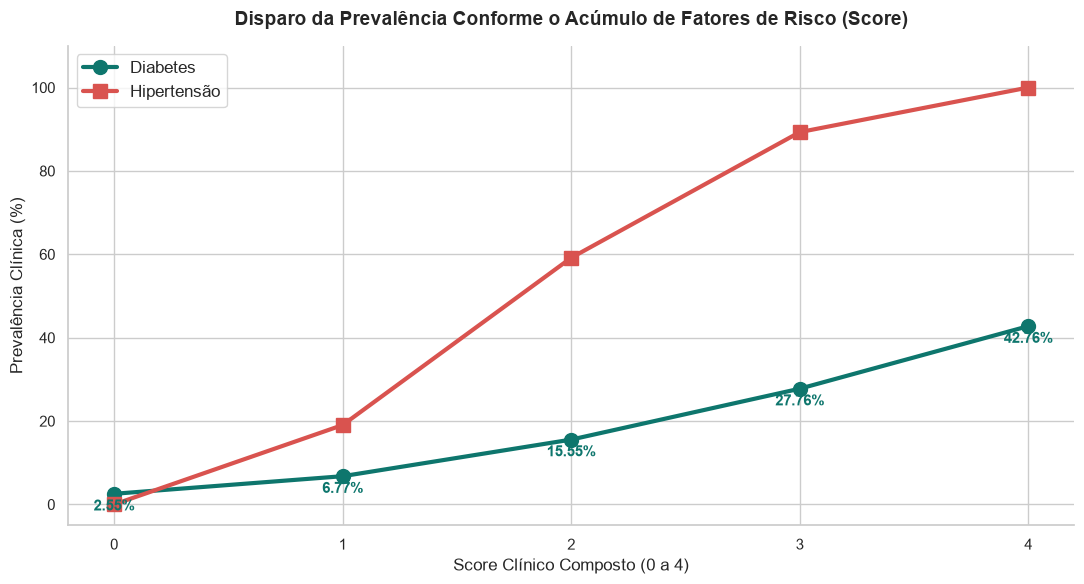

,Score,n,pct_distribuicao,pct_diabetes,pct_hipertensao
0,0.0,50684,19.98,2.55,0.00
1,1.0,75651,29.82,6.77,19.04
2,2.0,68667,27.07,15.55,59.16
3,3.0,45576,17.97,27.76,89.30
4,4.0,13102,5.16,42.76,100.00


In [3]:
# Agrupando resultados por Score
tabela_score = df_score.groupby('Score').agg(
    n=('Diabetes_binary', 'size'),
    pct_diabetes=('Diabetes_binary', 'mean'),
    pct_hipertensao=('HighBP', 'mean')
).reset_index()

tabela_score['pct_diabetes'] = (tabela_score['pct_diabetes'] * 100).round(2)
tabela_score['pct_hipertensao'] = (tabela_score['pct_hipertensao'] * 100).round(2)
tabela_score['pct_distribuicao'] = (tabela_score['n'] / len(df_score) * 100).round(2)

# Gráfico: Evolução do Risco (Score vs Doenças)
plt.figure(figsize=(11, 6))
plt.plot(tabela_score['Score'], tabela_score['pct_diabetes'], marker='o', markersize=10, linewidth=3, label='Diabetes', color=cor_primaria)
plt.plot(tabela_score['Score'], tabela_score['pct_hipertensao'], marker='s', markersize=10, linewidth=3, label='Hipertensão', color=cor_secundaria)

# Adicionando os valores da diabetes na linha
for i, val in enumerate(tabela_score['pct_diabetes']):
    plt.text(i, val - 4, f"{val}%", ha='center', color=cor_primaria, fontsize=11, fontweight='bold')

plt.title('Disparo da Prevalência Conforme o Acúmulo de Fatores de Risco (Score)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Prevalência Clínica (%)', fontsize=12)
plt.xlabel('Score Clínico Composto (0 a 4)', fontsize=12)
plt.xticks(tabela_score['Score'])
plt.ylim(-5, 110)
plt.legend(fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

display(tabela_score[['Score', 'n', 'pct_distribuicao', 'pct_diabetes', 'pct_hipertensao']])

In [ ]:
> **Conclusão:** O Score Sintético fornece a base científica para a triagem. A curva de tendência acima revela um disparo quase linear e agressivo da prevalência clínica:
1. **Baixo Risco (Score 0):** A prevalência de diabetes é residual (~2.5%) e não há registro de hipertensão isolada.
2. **Risco Extremo (Score 4):** A prevalência de diabetes atinge alarmantes 42.7%, enquanto a hipertensão atinge a totalidade absoluta do grupo.

Fica provado que os fatores de risco (sedentarismo, tabagismo, dislipidemia) não agem de forma isolada, possuindo um efeito cumulativo severo. Ranqueando os pacientes por esse score no front-end, o sistema permite priorizar o atendimento humano de casos críticos e automatizar o disparo de alertas preventivos.